## HW 4 - Q4 part (c) <br>
Filippa Mudsam

In [8]:
import numpy as np
import matplotlib.pyplot as plt

#create random numbers
rng = np.random.default_rng()

# F = {N,N'}
P = np.array([[0,   1/2, 1/2, 0,   0  ],    # U
              [1/4, 0,   0,   1/2, 1/4],    # I
              [3/4, 0,   0,   0,   1/4],    # M
              [0,   0,   0,   1,   0  ],    # F 
              [0,   0,   0,   0,   1  ]])   # A 

#label the states
names = ['U', 'I', 'M']

# values I calculated in problem 1 part c
h_hw    = [1/2, 5/8, 3/8]
g_hw    = [4, 2, 4]
tauF_hw = [4, 9/5, 5]
tauA_hw = [4, 7/3, 17/5]

In [9]:
# run chain from starting place x0 (U) until absorption A or F
def run_chain(x0):
    s = x0
    T = 0 # absorption time initializing
    while s != 3 and s != 4: # F and A
        cs = np.cumsum(P[s, :])#creating cumulative threshold
        s = int(np.searchsorted(cs, rng.random()))
        T += 1
    return T, s

Nsim = 10**4
T_all = {}       # absorption times all
fold_all = {}    # true if it ended in F

for x0 in range(3): # looping over states U,I,M
    T = np.zeros(Nsim, dtype=int)
    fate = np.zeros(Nsim, dtype=int)
    for j in range(Nsim):
        T[j], fate[j] = run_chain(x0)
    T_all[x0] = T
    fold_all[x0] = (fate == 3)

In [10]:
# tabulating true/hw values and simulated
for x0 in range(3):
    T = T_all[x0]
    fold = fold_all[x0]

    print(f'start {names[x0]}')
    print(f'  h:     simulated {np.mean(fold):.4f}   hw {h_hw[x0]:.4f}')
    print(f'  g:     simulated {np.mean(T):.4f}   hw {g_hw[x0]:.4f}')
    print(f'  tauF:  simulated {np.mean(T[fold]):.4f}   hw {tauF_hw[x0]:.4f}')
    print(f'  tauA:  simulated {np.mean(T[~fold]):.4f}   hw {tauA_hw[x0]:.4f}')

start U
  h:     simulated 0.5017   hw 0.5000
  g:     simulated 4.0020   hw 4.0000
  tauF:  simulated 3.9837   hw 4.0000
  tauA:  simulated 4.0205   hw 4.0000
start I
  h:     simulated 0.6267   hw 0.6250
  g:     simulated 2.0040   hw 2.0000
  tauF:  simulated 1.7924   hw 1.8000
  tauA:  simulated 2.3592   hw 2.3333
start M
  h:     simulated 0.3762   hw 0.3750
  g:     simulated 3.9910   hw 4.0000
  tauF:  simulated 5.0585   hw 5.0000
  tauA:  simulated 3.3472   hw 3.4000


In [11]:
# conditional PMF from I
# P_I(T = n | fate) = (Q^(n-1) R)[I, fate] / P_I(fate)
Q = P[0:3, 0:3]     
R = P[0:3, 3:5]    

n_max = 25
pmf_exact = np.zeros((n_max, 2))
#starting at I
q = np.array([0, 1, 0])        

for n in range(n_max):
    pmf_exact[n, :] = q @ R    
    q = q @ Q                 

pmf_exact[:, 0] = pmf_exact[:, 0]/h_hw[1]         
pmf_exact[:, 1] = pmf_exact[:, 1]/(1 - h_hw[1])  
n_theor = np.arange(1, n_max+1)

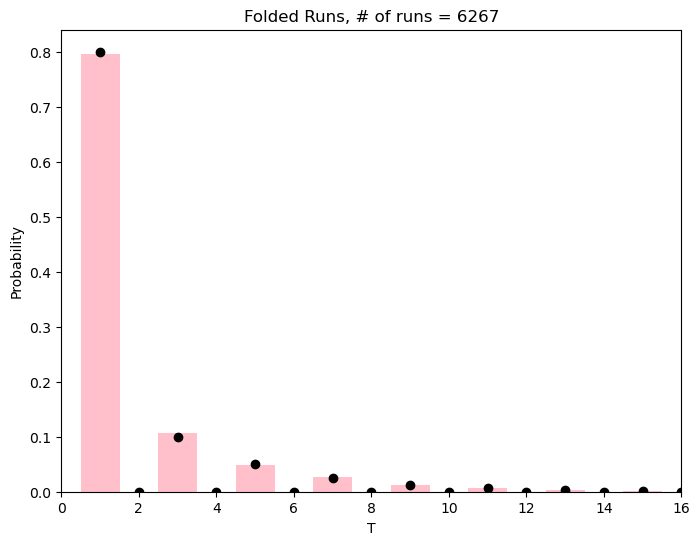

In [12]:
T_I = T_all[1]
fold_I = fold_all[1]

T_fold = T_I[fold_I]
counts = np.bincount(T_fold)              
emp_pmf = counts/len(T_fold) #normalize         
k_emp = np.arange(len(counts))

#Plot
plt.figure(1, figsize=(8, 6))
plt.bar(k_emp, emp_pmf, width=1, color = 'pink')
plt.plot(n_theor, pmf_exact[:, 0], 'o', color = 'black')
plt.xlim(0, 16)
plt.xlabel('T')
plt.ylabel('Probability')
plt.title(f'Folded Runs, # of runs = {len(T_fold)}')
plt.show()

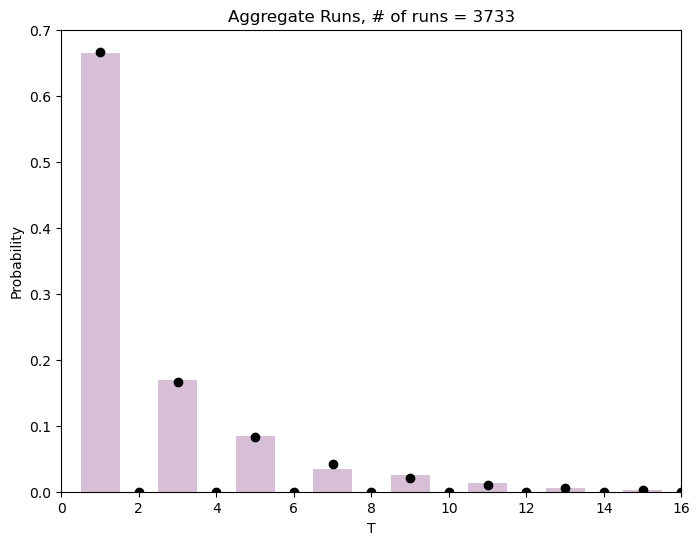

In [13]:
T_agg = T_I[~fold_I]
counts = np.bincount(T_agg)
emp_pmf = counts/len(T_agg) # normalize
k_emp = np.arange(len(counts))

#Plot
plt.figure(2, figsize=(8, 6))
plt.bar(k_emp, emp_pmf, width=1, color = 'thistle')
plt.plot(n_theor, pmf_exact[:, 1], 'o', color = 'black')
plt.xlabel('T')
plt.ylabel('Probability')
plt.title(f'Aggregate Runs, # of runs = {len(T_agg)}')
plt.xlim(0, 16)
plt.show()